# Tutorial 2 Data Exploration, LR and GLM (STAT3612)

- **Tutor**: Yinong Wang 
- **Office**: Rm103, RRS
- **Email**: wangyinong@connect.hku.hk

This tutorial berifly covers how to conduct simple real data exploration, and how to implement linear regression and Generalized Linear Models by `sklearn`, and R-style `statsmodels`.

## Outline
- [1. Exploratory Data Analysis](#Exploratory_Data_Analysis)

- [2. Linear Regression on Diabetes Dataset](#Linear_Regression_on_Diabetes_Dataset)

- [3. Logistic Regression on the Titanic Dataset](#Logistic_Regression_on_the_Titanic_Dataset)

- [4. Generalized Linear Regression Models with other Link Function](#Generalized_Linear_Regression_Models_with_other_Link_Function)

### Install Library

In [1]:
# ! pip install numpy
# ! pip install pandas
# ! pip install sklearn
# ! pip install seaborn 
# ! pip install matplotlib
# ! pip install statsmodels

### The packages to be used in this tutorial: 

- numpy 
- pandas
- seaborn 
    - `seaborn` is a Python data visualization library based on matplotlib. 
    - It provides a high-level interface for drawing attractive and informative statistical graphics.
    - [officail website](https://seaborn.pydata.org/)
- matplotlib
- sklearn
    - `sklearn` is the most useful and robust library for machine learning in Python. It provides a selection of efficient tools for machine learning and statistical modeling including classification, regression, clustering and dimensionality reduction via a consistence interface in Python. More details can be found [here](https://scikit-learn.org/stable/).
- statsmodels
     - `statsmodels` is a Python module that provides classes and functions for the estimation of many different statistical models, as well as for conducting statistical tests, and statistical data exploration. 
     - [officail website](https://www.statsmodels.org/stable/index.html)

###  1. Exploratory Data Analysis <a class="anchor" id="Exploratory_Data_Analysis"></a>
In this section, we introduce how to use Python and the plot skills we learned last week to conduct some descriptive analysis on a given dataset.  
Based on the type of data, we apply different approaches as follows:
- **General cases**: scatter plot matrix, descriptive statistics.
- **Categorical data**: bar plot.
- **Numerical data**: histogram, box plot.

#### The Iris Data
- The dataset is provided in the `sklearn` library.
- This data sets consists of 3 different types of irises (Setosa, Versicolour, and Virginica). (Iris is a kind of flower)  
- And their petal and sepal length. (two plant organ)
- The data is stored in a 150x4 numpy.ndarray.
- The rows being the samples and the columns being: Sepal Length, Sepal Width, Petal Length and Petal Width.
- [more details](https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html)

In [2]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets import load_iris
import pandas as pd 
# load iris dataset in pandas
iris = load_iris()
# select the feature from the dataset as X variable
DataX = pd.DataFrame(iris.data, columns=iris.feature_names)
# select the label from the dataset as Y variable
DataY = pd.DataFrame(iris.target, columns=["Species"])
# select the whole dataset
Data = pd.concat([DataX, DataY], axis = 1)

View the first 5 rows of X Variable

In [3]:
Data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


View the first 10 rows of X Variable

In [4]:
DataX.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


Data Summary: We use `.describe()` to generate descriptive statistics (count, mean, standard deviation, min, quantiles, max) for each variable.

In [5]:
DataX.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Sample count: We use `.value_counts()` to count the sample with some given attribute (Species here).

In [6]:
Data['Species'].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

Histogram plot: We use `.hist()` and `.tight_layout()` to plot histogram for X variable
- `.hist()` : calls matplotlib.pyplot.hist(), on each series in the DataFrame, resulting in one histogram per column.
- `.tight_layout()`: adjust the padding between and around subplots.

[[<Axes: title={'center': 'sepal length (cm)'}>
  <Axes: title={'center': 'sepal width (cm)'}>]
 [<Axes: title={'center': 'petal length (cm)'}>
  <Axes: title={'center': 'petal width (cm)'}>]]


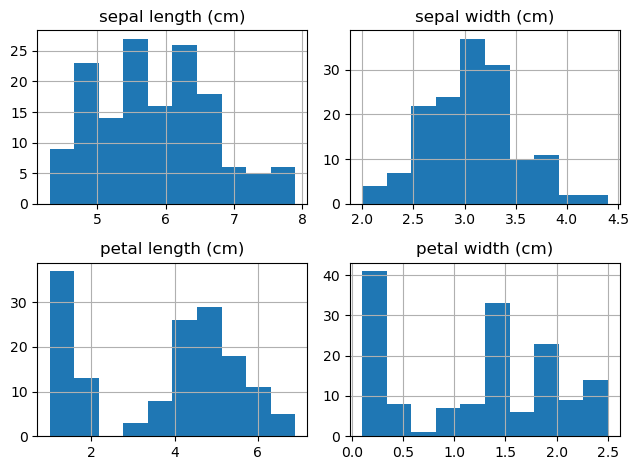

In [7]:
from matplotlib import pylab as plt
print(DataX.hist())
plt.tight_layout()

Scatter plot: Scatter plot matrix is applied to visualize the relationship among certain variables.

Text(0.5, 1.0, 'Petal length vs Sepal length')

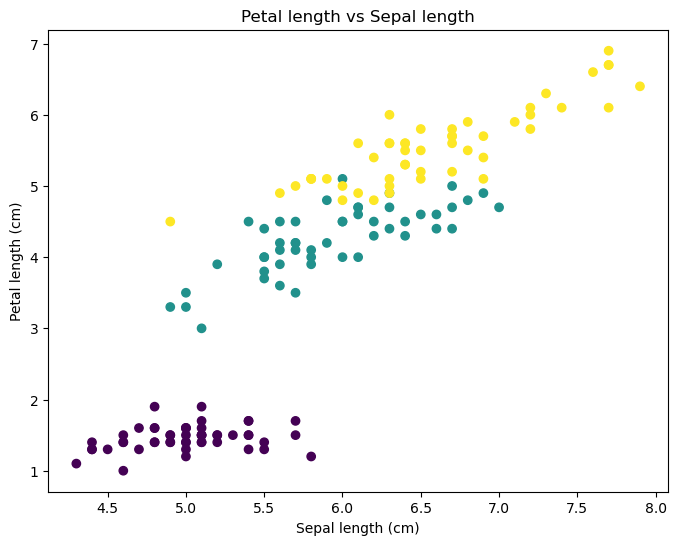

In [8]:
# create a new figure and define the size (width, hight)
plt.figure(1, (8, 6))
# c is for color, here means we want sample of different species has different color
plt.scatter(Data["sepal length (cm)"], Data["petal length (cm)"], c=Data["Species"])
# define title for x-axis, y-axis and the plot
plt.xlabel("Sepal length (cm)")
plt.ylabel("Petal length (cm)")
plt.title("Petal length vs Sepal length")

Pairwise scatter plot: We use `.pairplot()` in `seaborn` library to plot pairwise relationships in a dataset with only one line of code.  
That is histogram plot for each attribute and scatter plot for a pair of different attribute.

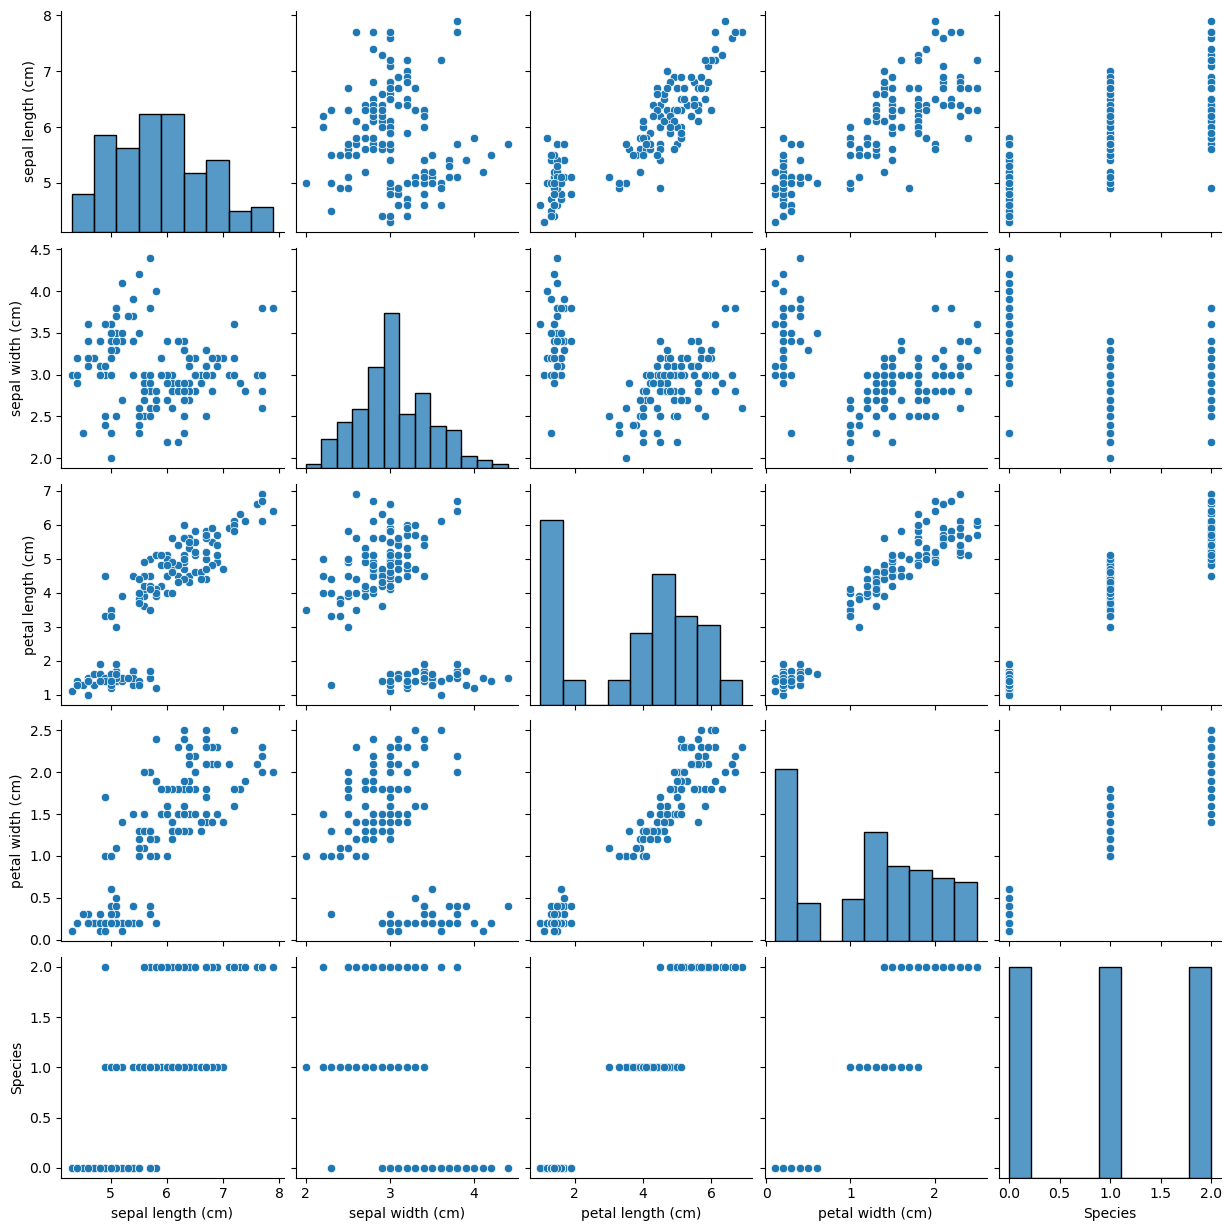

In [9]:
import seaborn as sns
sns.pairplot(Data)

A single scatter plot can visualize the relationship between two variables.

- **Relationship between pandas plot and matplotlib plot**:  All the plot functions in `pandas` are based on the corresponding `matplotlib` functions, which you may check through the return objects in `pandas`. Therefore plot functions of `pandas` are advanced wrap-up and share most of arguments (parameters) with their counterparts in `matplotlib`. So we will elaborate `matplotlib` functions in the following content:
    - `pandas`: convenient but limited.
    - `matplotlib`: flexible but complicated.
- **Plot functions in pandas**: In `pandas`, all specific plot functions such as bar plot are the subdivisions `pd.DataFrame.plot`, which you may treat as a simplified version of `matplotlib.pyplot`. We highly recommend you to browse the parameters of `pd.DataFrame.plot` ([link](https://pandas.pydata.org/pandas-docs/version/0.22/generated/pandas.DataFrame.plot.html)) before you read pandas implementation in upcoming subsections.

- e.g.: `.plot.scatter` has similar parameters with `plt.scatter`.

Box plot
- Box plot with some notations.
![Box plot](./box_plot.png)

- Use `plt.boxplot` to generate the box plot. Some parameters are listed below (reference: [link](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.boxplot.html#matplotlib.pyplot.boxplot)):
    - `x` : Array or a sequence of vectors. Each column of the array corresponds to one box plot.
    - `notch` : bool, optional (False). Set True to produce a notched box plot. You may refer to this [link](https://www.includehelp.com/python/notched-box-plot-in-python-using-matplotlib.aspx) to obtain the introduction of notched box plot.
    - `labels` : sequence, optional. Names for each box plot.
    - `boxprops`: dict, optional (None). Specify the style (properties, such as color) of the box. Set `patch_artist=True` if modify the facecolor.
    - `flierprops` : dict, optional (None). Specify the style (properties, such as color, size) of the fliers (outliers). 
    - Other `props` parameters are similar with `boxprops` and `flierprops`.
    - A detailed introduction and tutorial can be found in [link](https://matplotlib.org/3.1.1/gallery/pyplots/boxplot_demo_pyplot.html#sphx-glr-gallery-pyplots-boxplot-demo-pyplot-py).

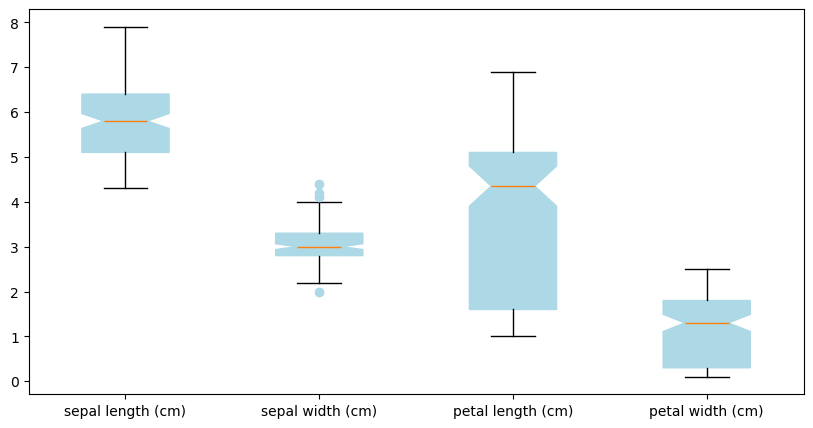

In [10]:
# properties of the fliers, marker: shape. 
# <=> rs = {'markerfacecolor'='lightblue', 'marker'='o'}
flierprops = dict(markerfacecolor='lightblue', marker='o',markeredgecolor='lightblue') 
# properties of the box, color: box line color; facecolor: fill-in color
boxprops = dict(facecolor='lightblue',color = 'lightblue') 
plt.figure(figsize=(10, 5))
plt.boxplot(DataX.values,labels=DataX.columns,
           flierprops=flierprops,boxprops=boxprops,
            patch_artist=True,notch = True)
plt.show()

- Given a data frame `df`, we call `df.boxplot` or `df.plot.box` to draw the box plot. And `pandas` plot is preferred when we consider group information.
    - `df.boxplot`: suitable for group boxplot.
    - `df.plot.box`: suitable for self-designed boxplot.

<Axes: >

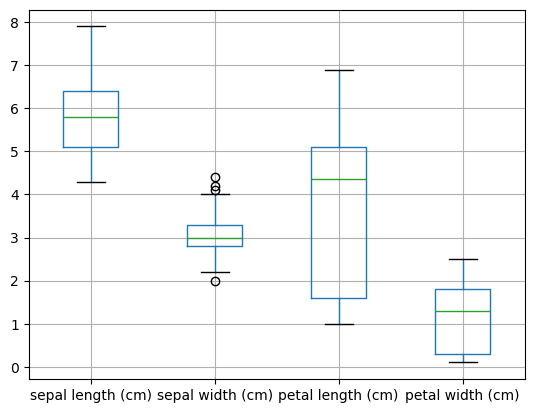

In [11]:
DataX.boxplot()

Correlation matrix: correlation between two attributes.  
We use `.corr()` to compute the correlation matrix, and use `.heatmap()` to plot the heatmap of the correlation matrix.
The default method in `.corr()` is `pearson`, you can also choose `kendall` or `spearman`. Details in this [link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html).

(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0.5, 0, 'sepal length (cm)'),
  Text(1.5, 0, 'sepal width (cm)'),
  Text(2.5, 0, 'petal length (cm)'),
  Text(3.5, 0, 'petal width (cm)')])

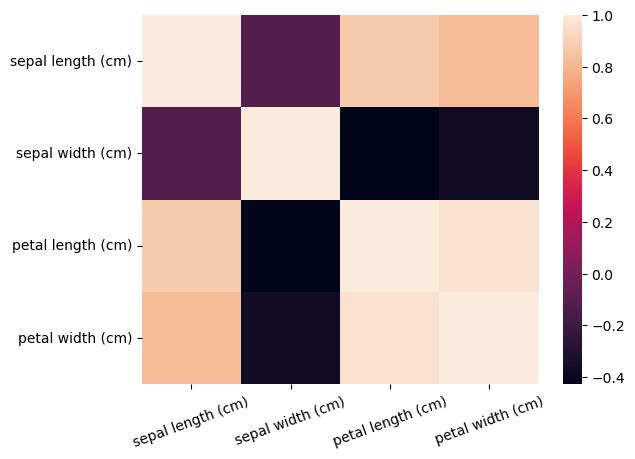

In [12]:
sns.heatmap(DataX.corr())
# rotate the title in x-axis
plt.xticks(rotation=20)

### 2. Linear Regression on Diabetes Dataset <a class="anchor" id="Linear_Regression_on_Diabetes_Dataset"></a>

In this section, we review some statistics in linear regression. 

Let $\mathbf{Z}\in\mathbb{R}^{n\times p}$ be the raw data matrix, $\mathbf{X}=(\mathbf{1}_n,\mathbf{Z})\in\mathbb{R}^{n\times(p+1)}$ be the design matrix and $\mathbf{y}\in\mathbb{R}^n$ be the response vector. We assume the data follows the linear model:
$$\mathbf{y}=\mathbf{X}\mathbf{\beta}+\mathbf{\varepsilon},$$
where $\mathbf{\beta}\in\mathbb{R}^{p+1}$ denotes the coefficient vector and $\mathbf{\varepsilon}$ follows the multivariate normal distribution $\mathcal{N}(\mathbf{0},\sigma^2\mathbf{I}_n)$.

#### The Diabetes Dataset
Here we use the diabetes dataset provided in the `sklearn` library.

In [13]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

In [14]:
# load the diabetes dataset in sklearn library
# here we denote the data matrix as Z
Z,y = load_diabetes(return_X_y=True, as_frame = True)

In [15]:
Z.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [16]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 442 entries, 0 to 441
Series name: target
Non-Null Count  Dtype  
--------------  -----  
442 non-null    float64
dtypes: float64(1)
memory usage: 3.6 KB


In [17]:
y.describe()

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

In `sklearn`, we first specify a regressor by `LinearRegression` and then feed the data through `.fit`.

In [18]:
# linear model estimated by sklearn
lm = LinearRegression() # create the regressor
lm.fit(Z,y) # fit the linear regression model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


- MLE of $\mathbf{\beta}$: $\hat{\mathbf{\beta}}=(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$

In [19]:
# the coefficient estimator
feature_names = load_diabetes().feature_names
feature_names = ['intercept']+feature_names
betahat = np.append(np.array(lm.intercept_),lm.coef_)
print("feature names:")
print(feature_names)
print("estimated coefficient")
print(betahat)

feature names:
['intercept', 'age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
estimated coefficient
[ 152.13348416  -10.0098663  -239.81564367  519.84592005  324.3846455
 -792.17563855  476.73902101  101.04326794  177.06323767  751.27369956
   67.62669218]


- Predictions: $\hat{\mathbf{y}}=\mathbf{X}\hat{\mathbf{\beta}}$

In [20]:
# prediction
y_pred = lm.predict(Z)
y_pred[:10] #print first 10 predictions

array([206.11667725,  68.07103297, 176.88279035, 166.91445843,
       128.46225834, 106.35191443,  73.89134662, 118.85423042,
       158.80889721, 213.58462442])

- Sum of squared error (SSE): $\mbox{SSE}=\sum_{i=1}^n(y_i-\hat{y}_i)^2$
- Total sum of squares (SST): $\mbox{SST}=\sum_{i=1}^n(y_i-\bar{y})^2$

In [21]:
# SST and SSE
sse = np.sum((y-y_pred)**2)
sst = np.sum((y-y.mean())**2)
print("SSE:")
print(sse)
print("SST:")
print(sst)

SSE:
1263985.7856333437
SST:
2621009.124434389


We can also calculate some other important statistics of the linear model and print them as a R-like summary table:

- $F$-statistic: $F=\frac{(SST-SSE)/p}{SSE/(n-p-1)}\sim F_{p,n-p-1}$
- Estimator of $\sigma^2$: $\hat{\sigma}^2=\frac{1}{n-p-1}\mbox{SSE}$
- R-squared: $R^2=1-\frac{\mbox{SSE}}{\mbox{SST}}$
- Adj. R-squared: $R^2_{\rm adj}=1-\frac{n-1}{n-p-1}(1-R^2)=1-\frac{n-1}{n-p-1}\frac{\mbox{SSE}}{\mbox{SST}}$
- The covariance matrix and its estimator: $\mbox{cov}(\hat{\mathbf{\beta}})=\sigma^2(\mathbf{X}^\top\mathbf{X})^{-1}$, $\hat{\mbox{cov}}(\hat{\mathbf{\beta}})=\hat{\sigma}^2(\mathbf{X}^\top\mathbf{X})^{-1}$

For $j=0,\dots,p$,

- Standard error of $\hat{\mathbf{\beta}}_j$: $\mbox{se}(\hat{\mathbf{\beta}}_j)=\hat{\sigma}\sqrt{(\mathbf{X}^\top\mathbf{X})^{-1}_{j,j}}$ 
- $t$-statistic: $t=\hat{\mathbf{\beta}}_j/\mbox{se}(\hat{\mathbf{\beta}}_j)\sim t_{n-p-1}$
- P value: $p=P(|t_{n-p-1}|>|t|)=2[1-P(t_{n-p-1}>|t|)]$
- Confidence interval: $\left[\hat{\mathbf{\beta}}_j-t_{1-\alpha/2,n-p-1}\mbox{se}(\hat{\mathbf{\beta}}_j),\hat{\mathbf{\beta}}_j+t_{1-\alpha/2,n-p-1}\mbox{se}(\hat{\mathbf{\beta}}_j)\right]$

In [22]:
# F-statistic
n, p = Z.shape
Fstat = (sst-sse)/p/(sse/(n-p-1))
# the estimator of residual variance
sig2hat = sse/(n-p-1)
# R-squared
R2 = 1-sse/sst
# Adj. R-squared
R2adj = 1-(n-1)*(1-R2)/(n-p-1)
# the standard error of betahat
X = np.hstack((np.ones((n,1)),Z))
stderr = np.sqrt(sig2hat*np.linalg.inv(np.dot(X.T,X)).diagonal())
# t-statsitic
tstat = betahat/stderr
# p value
from scipy.stats import t
pval = 2*(1 - t.cdf(np.abs(tstat),df = n-p-1))
# confidence interval
ci_lb = betahat-t.ppf(0.975,df=n-p-1)*stderr
ci_ub = betahat+t.ppf(0.975,df=n-p-1)*stderr
# self-defined summary table
my_summary = pd.DataFrame({
    ' ' : feature_names,
    'coef' : betahat,
    'std err' : stderr,
    't' : tstat,
    'P>|t|' : pval,
    '0.025' : ci_lb,
    '0.975' : ci_ub
})
print(my_summary.round(3))
print("R-Squared =", R2.round(3))
print("Adj. R-Squared =", R2adj.round(3))
print("F-Statistic =", Fstat.round(3))

                  coef  std err       t  P>|t|     0.025     0.975
0   intercept  152.133    2.576  59.061  0.000   147.071   157.196
1         age  -10.010   59.749  -0.168  0.867  -127.446   107.426
2         sex -239.816   61.222  -3.917  0.000  -360.147  -119.484
3         bmi  519.846   66.533   7.813  0.000   389.076   650.616
4          bp  324.385   65.422   4.958  0.000   195.799   452.970
5          s1 -792.176  416.680  -1.901  0.058 -1611.153    26.802
6          s2  476.739  339.030   1.406  0.160  -189.620  1143.098
7          s3  101.043  212.531   0.475  0.635  -316.684   518.770
8          s4  177.063  161.476   1.097  0.273  -140.315   494.441
9          s5  751.274  171.900   4.370  0.000   413.407  1089.140
10         s6   67.627   65.984   1.025  0.306   -62.064   197.318
R-Squared = 0.518
Adj. R-Squared = 0.507
F-Statistic = 46.272


What if we do not want to perform a regression using all of the variables?  For
example, in the above regression report,   `age` and `s3`  have a high $p$-value.
So we may wish to run a regression excluding this variable.
The following syntax results in a regression using all predictors except  `age`.

In [23]:
minus_age = Z[Z.columns.drop(['age', 's3'])] 
minus_age.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sex     442 non-null    float64
 1   bmi     442 non-null    float64
 2   bp      442 non-null    float64
 3   s1      442 non-null    float64
 4   s2      442 non-null    float64
 5   s4      442 non-null    float64
 6   s5      442 non-null    float64
 7   s6      442 non-null    float64
dtypes: float64(8)
memory usage: 27.8 KB


In [24]:
# linear model estimated by sklearn
lm = LinearRegression() # create the regressor
lm.fit(minus_age,y) # fit the linear regression model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
# the coefficient estimator
feature_names = list(minus_age.columns)
feature_names = ['intercept']+feature_names
betahat = np.append(np.array(lm.intercept_),lm.coef_)
print("feature names:")
print(feature_names)
print("estimated coefficient")
print(betahat)

feature names:
['intercept', 'sex', 'bmi', 'bp', 's1', 's2', 's4', 's5', 's6']
estimated coefficient
[ 152.13348416 -242.05391655  518.78694298  321.50211182 -620.64733925
  353.94710061  127.21514617  691.92417125   67.14286715]


In [26]:
# prediction
y_pred = lm.predict(minus_age)
y_pred[:10] #print first 10 predictions

array([206.28774046,  67.73636012, 177.21096207, 165.85234157,
       128.57893728, 105.65293669,  75.22912484, 120.28746224,
       159.91736106, 213.75016176])

In [27]:
# SST and SSE
sse = np.sum((y-y_pred)**2)
sst = np.sum((y-y.mean())**2)
print("SSE:")
print(sse)
print("SST:")
print(sst)

SSE:
1264714.5798706817
SST:
2621009.124434389


#### Interaction Terms
It is easy to include interaction terms in a linear model:

In [28]:
new_Z = Z.copy()
new_Z['bmi_bp'] = new_Z['bmi'] * new_Z['bp']
new_Z

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,bmi_bp
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,0.001349
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,0.001355
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,-0.000252
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,0.000425
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,-0.000796
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,0.001175
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,0.001076
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,-0.000275
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,0.000047


In [29]:
# linear model estimated by sklearn
lm = LinearRegression() # create the regressor
lm.fit(new_Z,y) # fit the linear regression model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
# the coefficient estimator
feature_names = list(new_Z.columns)
feature_names = ['intercept']+feature_names
betahat = np.append(np.array(lm.intercept_),lm.coef_)
print("feature names:")
print(feature_names)
print("estimated coefficient")
print(betahat)

feature names:
['intercept', 'age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'bmi_bp']
estimated coefficient
[ 149.02886321   10.3482117  -244.79991631  504.40142963  295.31342641
 -834.20610192  550.61611236  102.80571658  166.80477765  768.79465057
   71.22514442 3470.42143612]


#### Higher-order Polynomial Terms
We can also include polynomial functions in a linear model.

In [31]:
new_Z = Z.copy()
new_Z['bmi^3'] = new_Z['bmi'].pow(3)
new_Z

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,bmi^3
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,0.000235
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,-0.000136
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,0.000088
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,-0.000002
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,-0.000048
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,0.000008
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,-0.000004
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,-0.000004
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,0.000060


In [32]:
# linear model estimated by sklearn
lm = LinearRegression() # create the regressor
lm.fit(new_Z,y) # fit the linear regression model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
# the coefficient estimator
feature_names = list(new_Z.columns)
feature_names = ['intercept']+feature_names
betahat = np.append(np.array(lm.intercept_),lm.coef_)
print("feature names:")
print(feature_names)
print("estimated coefficient")
print(betahat)

feature names:
['intercept', 'age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'bmi^3']
estimated coefficient
[ 1.51445294e+02 -6.81997252e+00 -2.45871813e+02  4.36548583e+02
  3.27831519e+02 -7.60111073e+02  4.66105730e+02  7.31941730e+01
  1.56657623e+02  7.49234973e+02  7.02453642e+01  1.07277996e+04]


#### Using `PolynomialFeatures` 

Besides, interaction terms and higher-order polynomial terms can be included using the `PolynomialFeatures` class from the preprocessing module. 

In [34]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# PolynomialFeatures with degree=2 will generate interaction terms and squares of input features
poly_features = PolynomialFeatures(degree=2)
lm = LinearRegression()
interaction_model = make_pipeline(poly_features,lm)
interaction_model.fit(Z, y)

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [35]:
# Get the feature names
input_feature_names = list(Z.columns)
feature_names = poly_features.get_feature_names_out(input_features=input_feature_names)
feature_names

array(['1', 'age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'age^2', 'age sex', 'age bmi', 'age bp', 'age s1', 'age s2',
       'age s3', 'age s4', 'age s5', 'age s6', 'sex^2', 'sex bmi',
       'sex bp', 'sex s1', 'sex s2', 'sex s3', 'sex s4', 'sex s5',
       'sex s6', 'bmi^2', 'bmi bp', 'bmi s1', 'bmi s2', 'bmi s3',
       'bmi s4', 'bmi s5', 'bmi s6', 'bp^2', 'bp s1', 'bp s2', 'bp s3',
       'bp s4', 'bp s5', 'bp s6', 's1^2', 's1 s2', 's1 s3', 's1 s4',
       's1 s5', 's1 s6', 's2^2', 's2 s3', 's2 s4', 's2 s5', 's2 s6',
       's3^2', 's3 s4', 's3 s5', 's3 s6', 's4^2', 's4 s5', 's4 s6',
       's5^2', 's5 s6', 's6^2'], dtype=object)

In [36]:
# the coefficient estimator
feature_names = feature_names
feature_names = ['intercept']+feature_names
betahat = np.append(np.array(lm.intercept_),lm.coef_)
print("feature names:")
print(feature_names)
print("estimated coefficient")
print(betahat)

feature names:
['intercept1' 'interceptage' 'interceptsex' 'interceptbmi' 'interceptbp'
 'intercepts1' 'intercepts2' 'intercepts3' 'intercepts4' 'intercepts5'
 'intercepts6' 'interceptage^2' 'interceptage sex' 'interceptage bmi'
 'interceptage bp' 'interceptage s1' 'interceptage s2' 'interceptage s3'
 'interceptage s4' 'interceptage s5' 'interceptage s6' 'interceptsex^2'
 'interceptsex bmi' 'interceptsex bp' 'interceptsex s1' 'interceptsex s2'
 'interceptsex s3' 'interceptsex s4' 'interceptsex s5' 'interceptsex s6'
 'interceptbmi^2' 'interceptbmi bp' 'interceptbmi s1' 'interceptbmi s2'
 'interceptbmi s3' 'interceptbmi s4' 'interceptbmi s5' 'interceptbmi s6'
 'interceptbp^2' 'interceptbp s1' 'interceptbp s2' 'interceptbp s3'
 'interceptbp s4' 'interceptbp s5' 'interceptbp s6' 'intercepts1^2'
 'intercepts1 s2' 'intercepts1 s3' 'intercepts1 s4' 'intercepts1 s5'
 'intercepts1 s6' 'intercepts2^2' 'intercepts2 s3' 'intercepts2 s4'
 'intercepts2 s5' 'intercepts2 s6' 'intercepts3^2' 'intercept

#### R-style Linear Regression

Add a constant to the predictor variables. This is needed to include the intercept (bias) term in the regression model:

In [37]:
Z_const = Z.copy()
Z_const['const'] = 1.0

Ordinary Least Squares: `class statsmodels.regression.linear_model.OLS`.

In [38]:
import statsmodels.api as sm

model = sm.OLS(y, Z_const)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     46.27
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           3.83e-62
Time:                        17:19:09   Log-Likelihood:                -2386.0
No. Observations:                 442   AIC:                             4794.
Df Residuals:                     431   BIC:                             4839.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
age          -10.0099     59.749     -0.168      0.8

Quantities of interest can be extracted directly from the fitted model. Type dir(results) for a full list. Here are some examples:

In [39]:
print("Parameters: ", results.params)
print("R2: ", results.rsquared)

Parameters:  age      -10.009866
sex     -239.815644
bmi      519.845920
bp       324.384646
s1      -792.175639
s2       476.739021
s3       101.043268
s4       177.063238
s5       751.273700
s6        67.626692
const    152.133484
dtype: float64
R2:  0.5177484222203499


We have the same results as the sklearn example.

We can also detect the multicollinearity with the report:

In [40]:
new_Z = Z.copy()
new_Z['2_bmi'] = new_Z['bmi'] * 2.0
new_Z = new_Z[['bmi','2_bmi']]
model = sm.OLS(y, new_Z)
results = model.fit()
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:                 target   R-squared (uncentered):                   0.070
Model:                            OLS   Adj. R-squared (uncentered):              0.068
Method:                 Least Squares   F-statistic:                              33.27
Date:                Sun, 22 Feb 2026   Prob (F-statistic):                    1.51e-08
Time:                        17:19:09   Log-Likelihood:                         -2882.5
No. Observations:                 442   AIC:                                      5767.
Df Residuals:                     441   BIC:                                      5771.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

### 3. Logistic Regression on the Titanic Dataset <a class="anchor" id="Logistic_Regression_on_the_Titanic_Dataset"></a>
- In logistic regression, we assume the binary response $y \in \{0,1\}$ given numerical features $X=x$ follows a Bernoulli distribution with success probability $p$, which satisfy:
$$
    p = \frac1{1+e^{-\beta^T x}}.
$$

#### The Titanic Dataset
Here we use the Titanic dataset provided in [kaggle](https://www.kaggle.com/c/titanic/data) as a example of applying logistic regression. 

The training data is in `train.csv`.

In [41]:
# Load the training dataset and preview
titanic = pd.read_csv("./train.csv") # specify your file directory here.
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


The main task on this dataset is to predict the 'Survived' column (i.e., if each passenger survived on the Titanic) by the remain columns of featrues.

#### Preprocessing
##### Missing Values

In [42]:
# Misssing value frequencies for each feature
psg_num = titanic.shape[0]
print('{}\n'.format(titanic.isnull().sum()))
print((titanic.isnull().sum()/psg_num).apply(lambda x: format(x, '.2%')))

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

PassengerId     0.00%
Survived        0.00%
Pclass          0.00%
Name            0.00%
Sex             0.00%
Age            19.87%
SibSp           0.00%
Parch           0.00%
Ticket          0.00%
Fare            0.00%
Cabin          77.10%
Embarked        0.22%
dtype: object


- '**Cabin**': 77% records are missing, which means that imputing information and using this variable for prediction is probably not wise. Also note that 'Cabin' takes non-numerical value, which is not suitable to use in logistic regression. We'll ignore this variable in our model.

- '**Embarked**': only 2(0.22%) missing values. Since 'Embarked' has only a few categories (actually only 3), we can just impute with the top most category.

<Axes: title={'center': 'Embarked'}, xlabel='Embarked'>

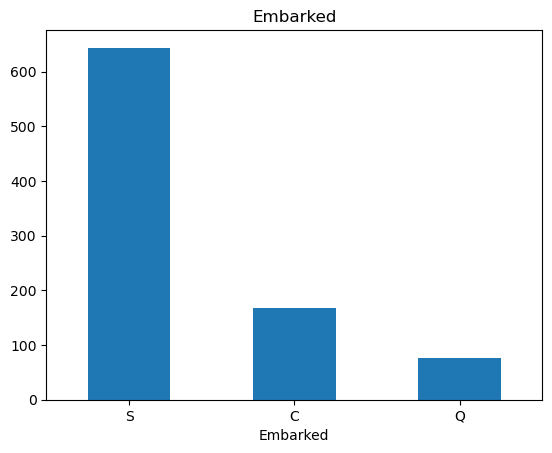

In [43]:
import matplotlib.pyplot as plt 
embarked_counts = titanic['Embarked'].value_counts()
embarked_counts.plot.bar(x='Embarked', y=embarked_counts, rot=0, title='Embarked')

From above we know the 'S' category has most counts within 'Embarked'. So we'll impute those 2 NaN's with 'S’.

- '**Age**': around 20% are missing. Let's see what the 'Age' feature looks like in general first.

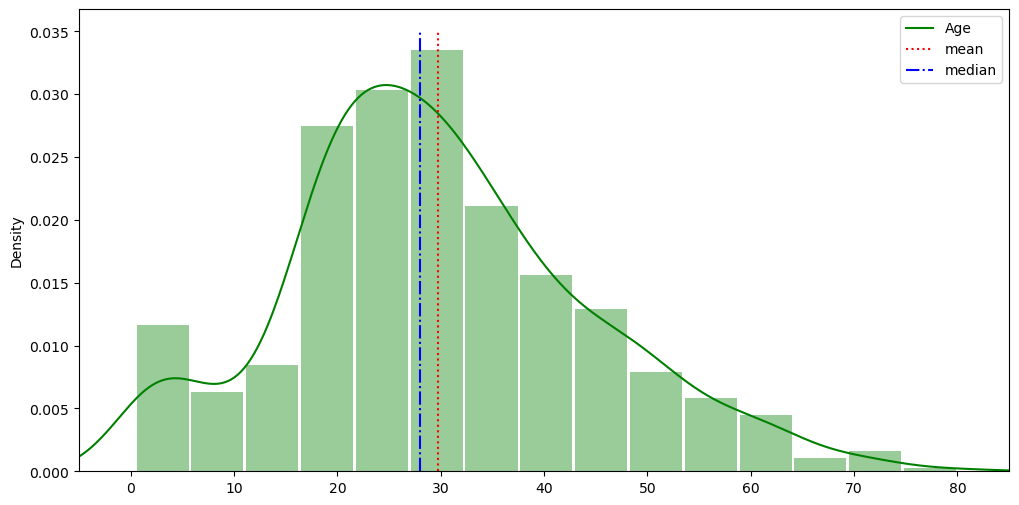

In [44]:
# draw histogram for 'Age'
titanic['Age'].hist(bins=15, density=True, color='green', alpha=0.4, rwidth=0.95, figsize=(12,6))
titanic['Age'].plot(kind='density', color='green')

# draw mean and median line
x1 = titanic['Age'].mean(skipna=True)
x2 = titanic['Age'].median(skipna=True)
plt.vlines(x=x1,ymin=0,ymax=0.035,color='r',linestyles=':',label = 'mean')
plt.vlines(x2,0,0.035,'b','-.',label = 'median')

plt.legend()
plt.xlim(-5,85)
plt.show()

Since 'Age' is right skewed, using the mean might give us biased results by filling in ages that are older than desired. To deal with this, we'll use its median to impute the missing values.

We now impute all the missing values according to the above discussion.

In [45]:
# impute all missing values
titanic_data = titanic.copy()
titanic_data.drop('Cabin', axis=1, inplace=True)
titanic_data['Embarked'].fillna(titanic['Embarked'].value_counts().idxmax(), inplace=True)
titanic_data['Age'].fillna(titanic['Age'].median(skipna=True), inplace=True)
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [46]:
titanic_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


##### Some More Preprocessing
Before started to do regression, we will need to drop some of the unuseful columns (feature selection).

In [47]:
# drop unuseful columns
titanic_data.drop('PassengerId', axis=1, inplace=True)
titanic_data.drop('Name', axis=1, inplace=True)
titanic_data.drop('Ticket', axis=1, inplace=True)

Because the response variables in logistic regression only takes numerical values, we will also need to create categorical variables for features 'Pclass', 'Sex', and 'Embarked'.

In [48]:
#create categorical variables
titanic_final = titanic_data.copy()
titanic_final['newSex'] = titanic_data['Sex'].map({'male': 1,'female': 0})
titanic_final['newEmbarked'] = titanic_data['Embarked'].map({'Q':2, 'S': 1,'C': 0})
titanic_final.drop('Sex', axis=1, inplace=True)
titanic_final.drop('Embarked', axis=1, inplace=True)
titanic_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Age          891 non-null    float64
 3   SibSp        891 non-null    int64  
 4   Parch        891 non-null    int64  
 5   Fare         891 non-null    float64
 6   newSex       891 non-null    int64  
 7   newEmbarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


In [49]:
titanic_final.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare,newSex,newEmbarked
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208,0.647587,0.897868
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429,0.477990,0.514624
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000,1.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000,1.000000
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,1.000000,1.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,2.000000


Because we only have trainig data, to evaluate the performance, we will split the data into training (80%) and testing (20%) set with a random seed.

In [50]:
# split the initial dataset
from sklearn.model_selection import train_test_split
x = titanic_final.iloc[:,1:]
y = titanic_final['Survived']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=3612)

In `sklearn`, we first specify a regressor by `LogisticRegression` and then feed the data through `.fit`.

Detail description of `LogisticRegression` can be found in [link](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression).

In [51]:
from sklearn.linear_model import LogisticRegression

# create regressor
logreg = LogisticRegression(C=1e8, solver='newton-cg')
# fit the model with trianing data
logreg.fit(x_train, y_train)
# predictions of training data
y_pred_train = logreg.predict(x_train)
# predictions of test data
y_pred_test = logreg.predict(x_test)
#
print("Coefficients :", np.round(logreg.intercept_,4), np.round(logreg.coef_,4))

Coefficients : [4.9415] [[-1.0514e+00 -3.4700e-02 -3.1510e-01 -2.5830e-01  2.7000e-03 -2.9074e+00
  -1.7570e-01]]


#### R-style Logistic Regression

Add a constant to the predictor variables. This is needed to include the intercept (bias) term in the regression model:

In [52]:
x_train_add_const = x_train.copy()
x_train_add_const['const'] = 1
x_train_add_const

,Pclass,Age,SibSp,Parch,Fare,newSex,newEmbarked,const
60,3,22.0,0,0,7.2292,1,0,1
373,1,22.0,0,0,135.6333,1,0,1
85,3,33.0,3,0,15.8500,0,1,1
535,2,7.0,0,2,26.2500,0,1,1
152,3,55.5,0,0,8.0500,1,1,1
...,...,...,...,...,...,...,...,...
270,1,28.0,0,0,31.0000,1,1,1
562,2,28.0,0,0,13.5000,1,1,1
825,3,28.0,0,0,6.9500,1,2,1
37,3,21.0,0,0,8.0500,1,1,1


Create a GLM object with the logistic regression family and fit:

In [53]:
glm_binom = sm.GLM(y_train, x_train_add_const, family=sm.families.Binomial())
res = glm_binom.fit()
print(res.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               Survived   No. Observations:                  712
Model:                            GLM   Df Residuals:                      704
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -306.51
Date:                Sun, 22 Feb 2026   Deviance:                       613.02
Time:                        17:19:09   Pearson chi2:                     729.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3664
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Pclass         -1.0514      0.160     -6.588      

we can see that we have the same results as the sklearn example.

### 4. Generalized Linear Regression Models with other Link Function:  <a class="anchor" id="Generalized_Linear_Regression_Models_with_other_Link_Function"></a>

We can change the link function by setting different `family` parameter, now let's see a case with Gaussian distribution with a noncanonical link, first we create some artificial data:

In [54]:
nobs2 = 100
x = np.arange(nobs2)
np.random.seed(54321)
X = np.column_stack((x,x**2))
X = sm.add_constant(X, prepend=False)
lny = np.exp(-(.03*x + .0001*x**2 - 1.0)) + .001 * np.random.rand(nobs2)

In logistic regression, we set the `family` as `sm.families.Binomial()`, in this example, we simply set it as `sm.families.Gaussian(sm.families.links.Log())` to meet our requirements.

In [55]:
gauss_log = sm.GLM(lny, X, family=sm.families.Gaussian(sm.families.links.Log()))
gauss_log_results = gauss_log.fit()
print(gauss_log_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       97
Model Family:                Gaussian   Df Model:                            2
Link Function:                    Log   Scale:                      1.0531e-07
Method:                          IRLS   Log-Likelihood:                 662.92
Date:                Sun, 22 Feb 2026   Deviance:                   1.0215e-05
Time:                        17:19:09   Pearson chi2:                 1.02e-05
No. Iterations:                     7   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.0300    5.6e-06  -5361.316      0.0

### Thank you!